# NB5: Publication Figures
- **Purpose:** Produce all 10 requested publication-quality figures, exported to `.pdf` and `.png`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy import stats
import os
import sys, os; sys.path.append(os.path.abspath(".")); sys.path.append(os.path.abspath("..")); import helpers
import warnings

warnings.filterwarnings("ignore")

# Output directory
if not os.path.exists('figures'):
    os.makedirs('figures')

# Global plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

def save_fig(fig, name):
    fig.savefig(f'figures/{name}.png', bbox_inches='tight')
    fig.savefig(f'figures/{name}.pdf', bbox_inches='tight')
    
print("Setup complete. Ready to generate figures.")


Setup complete. Ready to generate figures.


In [2]:
# 1. Load data
df = helpers.load_data('exclude', filter_completers=True)
df_full = helpers.load_data('clinical') # Keep all images for distribution/noise figures
df_part = helpers.participant_summary(df)
df_img = helpers.image_summary(df_full)

df['human_correct_plat_int'] = df['human_correct_plat'].astype(int)
df['human_correct_orig_int'] = df['human_correct_original'].astype(int)


Data Loading: 51 participants selected (from 68 initial).
Data Loading: 51 participants selected (from 68 initial).


## Figure 1: GT Transition Sankey

In [3]:
print("Generating Fig 1: GT Transition Sankey")

source, target, value = [], [], []
for o in [0, 2, 3, 4]:
    for p in [0, 1, 2, 3, 4]:
        count = len(df_img[(df_img['gt_original']==o) & (df_img['gt_plat_kl']==p)])
        if count > 0:
            source.append(o)
            target.append(p + 5)
            value.append(count)

labels = ["Orig KL0", "Orig KL1", "Orig KL2", "Orig KL3", "Orig KL4",
          "Plat KL0", "Plat KL1", "Plat KL2", "Plat KL3", "Plat KL4"]

fig_sankey = go.Figure(data=[go.Sankey(
    node = dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=labels),
    link = dict(source=source, target=target, value=value)
)])
fig_sankey.update_layout(title_text="Original vs Platinum GT Label Flow", font_size=12, width=800, height=500)

try:
    fig_sankey.write_image("figures/Fig1_Transition_Sankey.png", scale=3)
    fig_sankey.write_image("figures/Fig1_Transition_Sankey.pdf")
except Exception as e:
    print("kaleido export failed, you may need to install kaleido. Returning HTML instead.")
    fig_sankey.show()


Generating Fig 1: GT Transition Sankey
kaleido export failed, you may need to install kaleido. Returning HTML instead.


## Figure 2: Label Noise Summary (Two-panel)

Generating Fig 2: Label Noise Summary


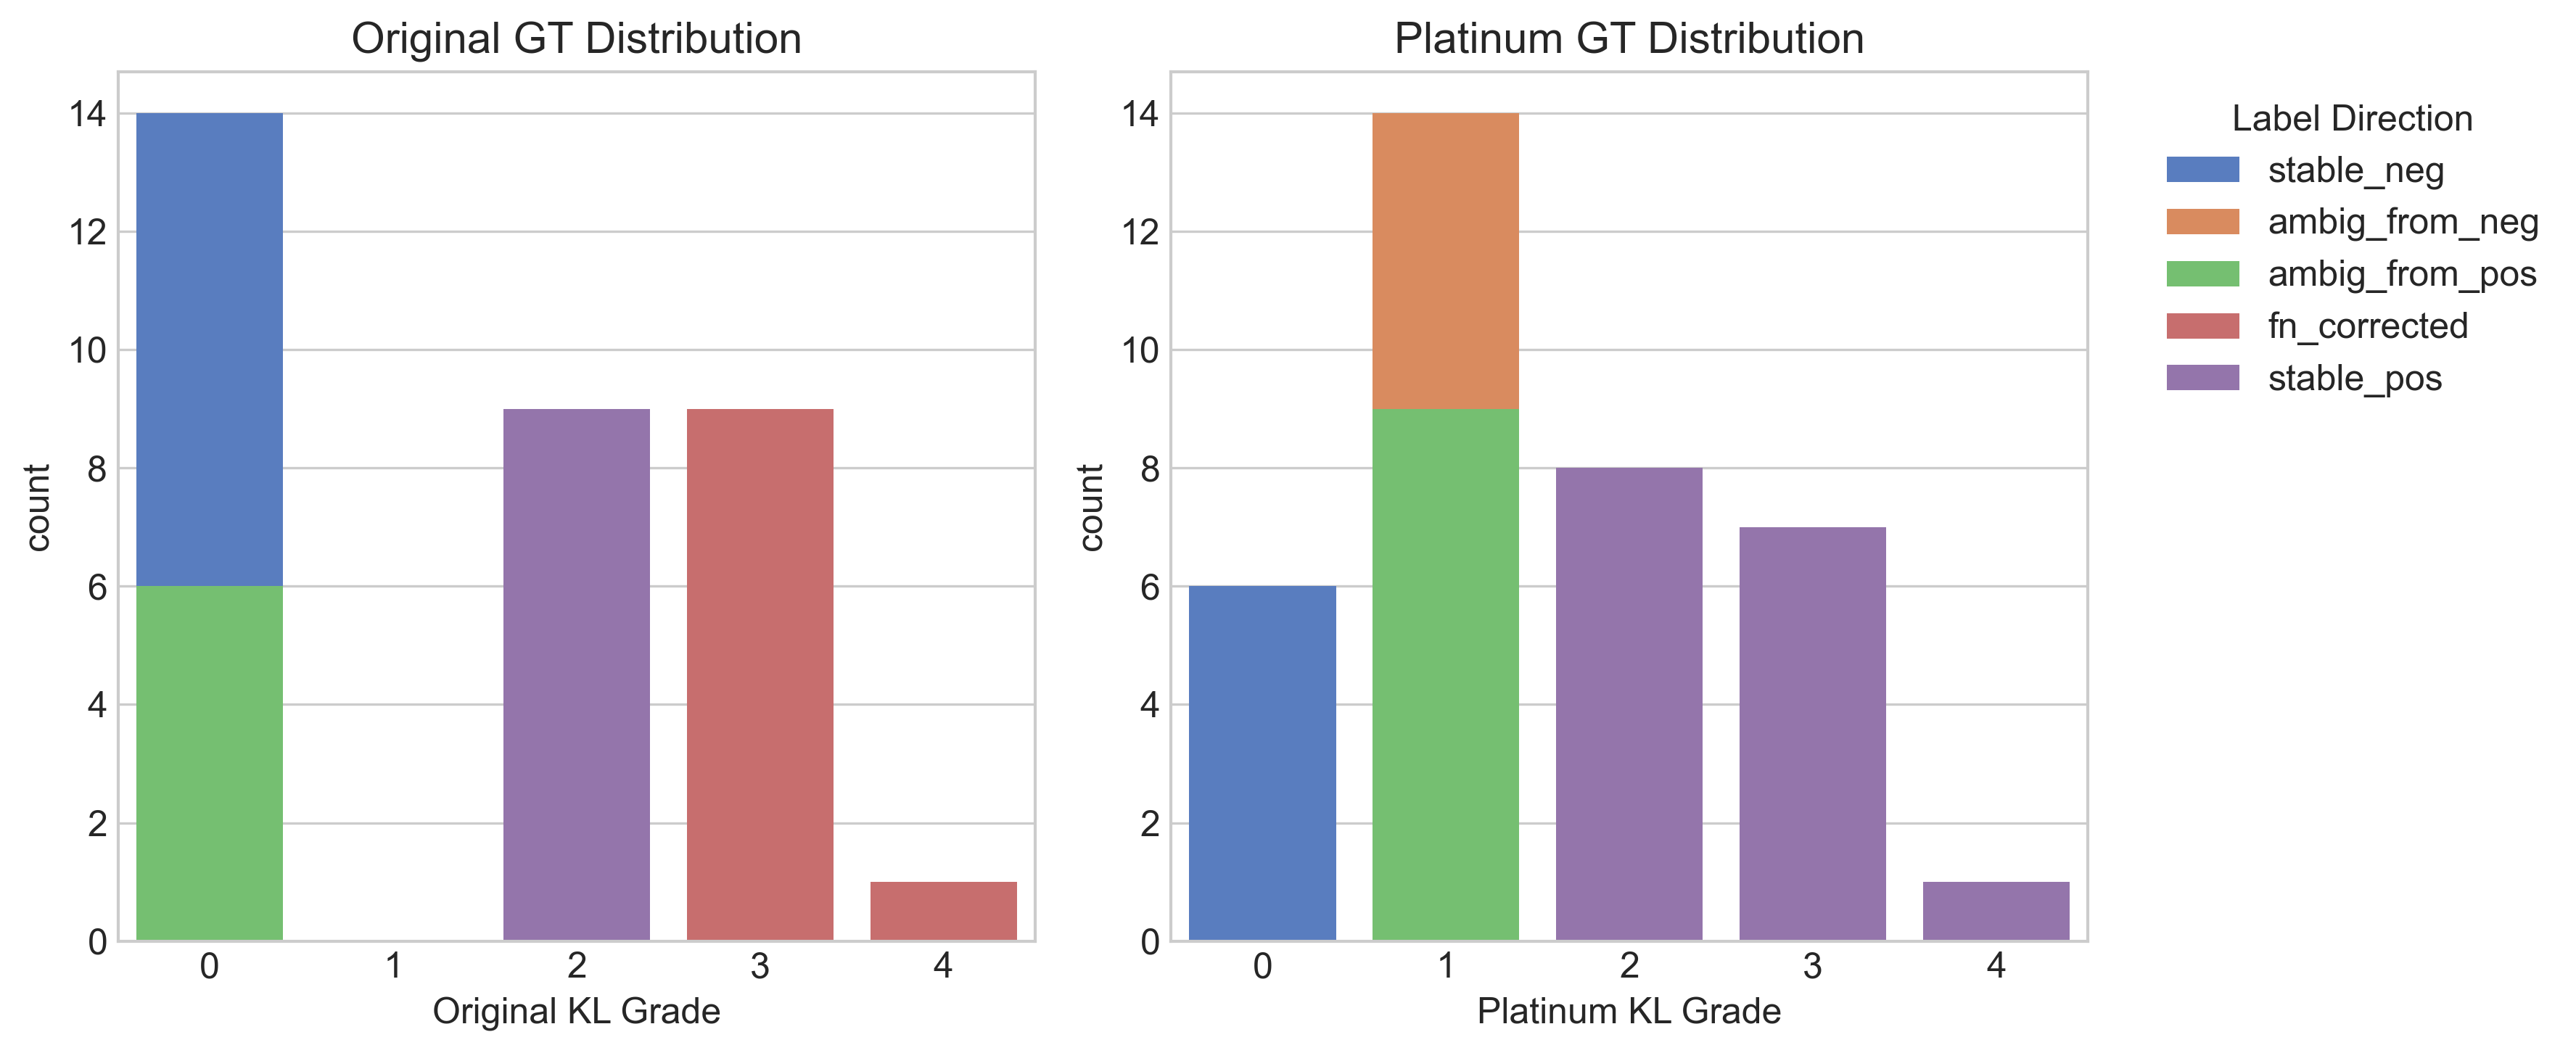

In [4]:
print("Generating Fig 2: Label Noise Summary")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original
sns.countplot(data=df_img, x='gt_original', hue='label_direction', ax=ax1, dodge=False, palette='muted', order=[0, 1, 2, 3, 4])
ax1.set_title('Original GT Distribution')
ax1.set_xlabel('Original KL Grade')

# Platinum
sns.countplot(data=df_img, x='gt_plat_kl', hue='label_direction', ax=ax2, dodge=False, palette='muted', order=[0, 1, 2, 3, 4])
ax2.set_title('Platinum GT Distribution')
ax2.set_xlabel('Platinum KL Grade')

ax1.legend_.remove()
ax2.legend(title='Label Direction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_fig(fig, 'Fig2_Label_Noise_Summary')
plt.show()


## Figure 3: Accuracy Paradox

Generating Fig 3: Accuracy Paradox
Data Loading: 51 participants selected (from 68 initial).


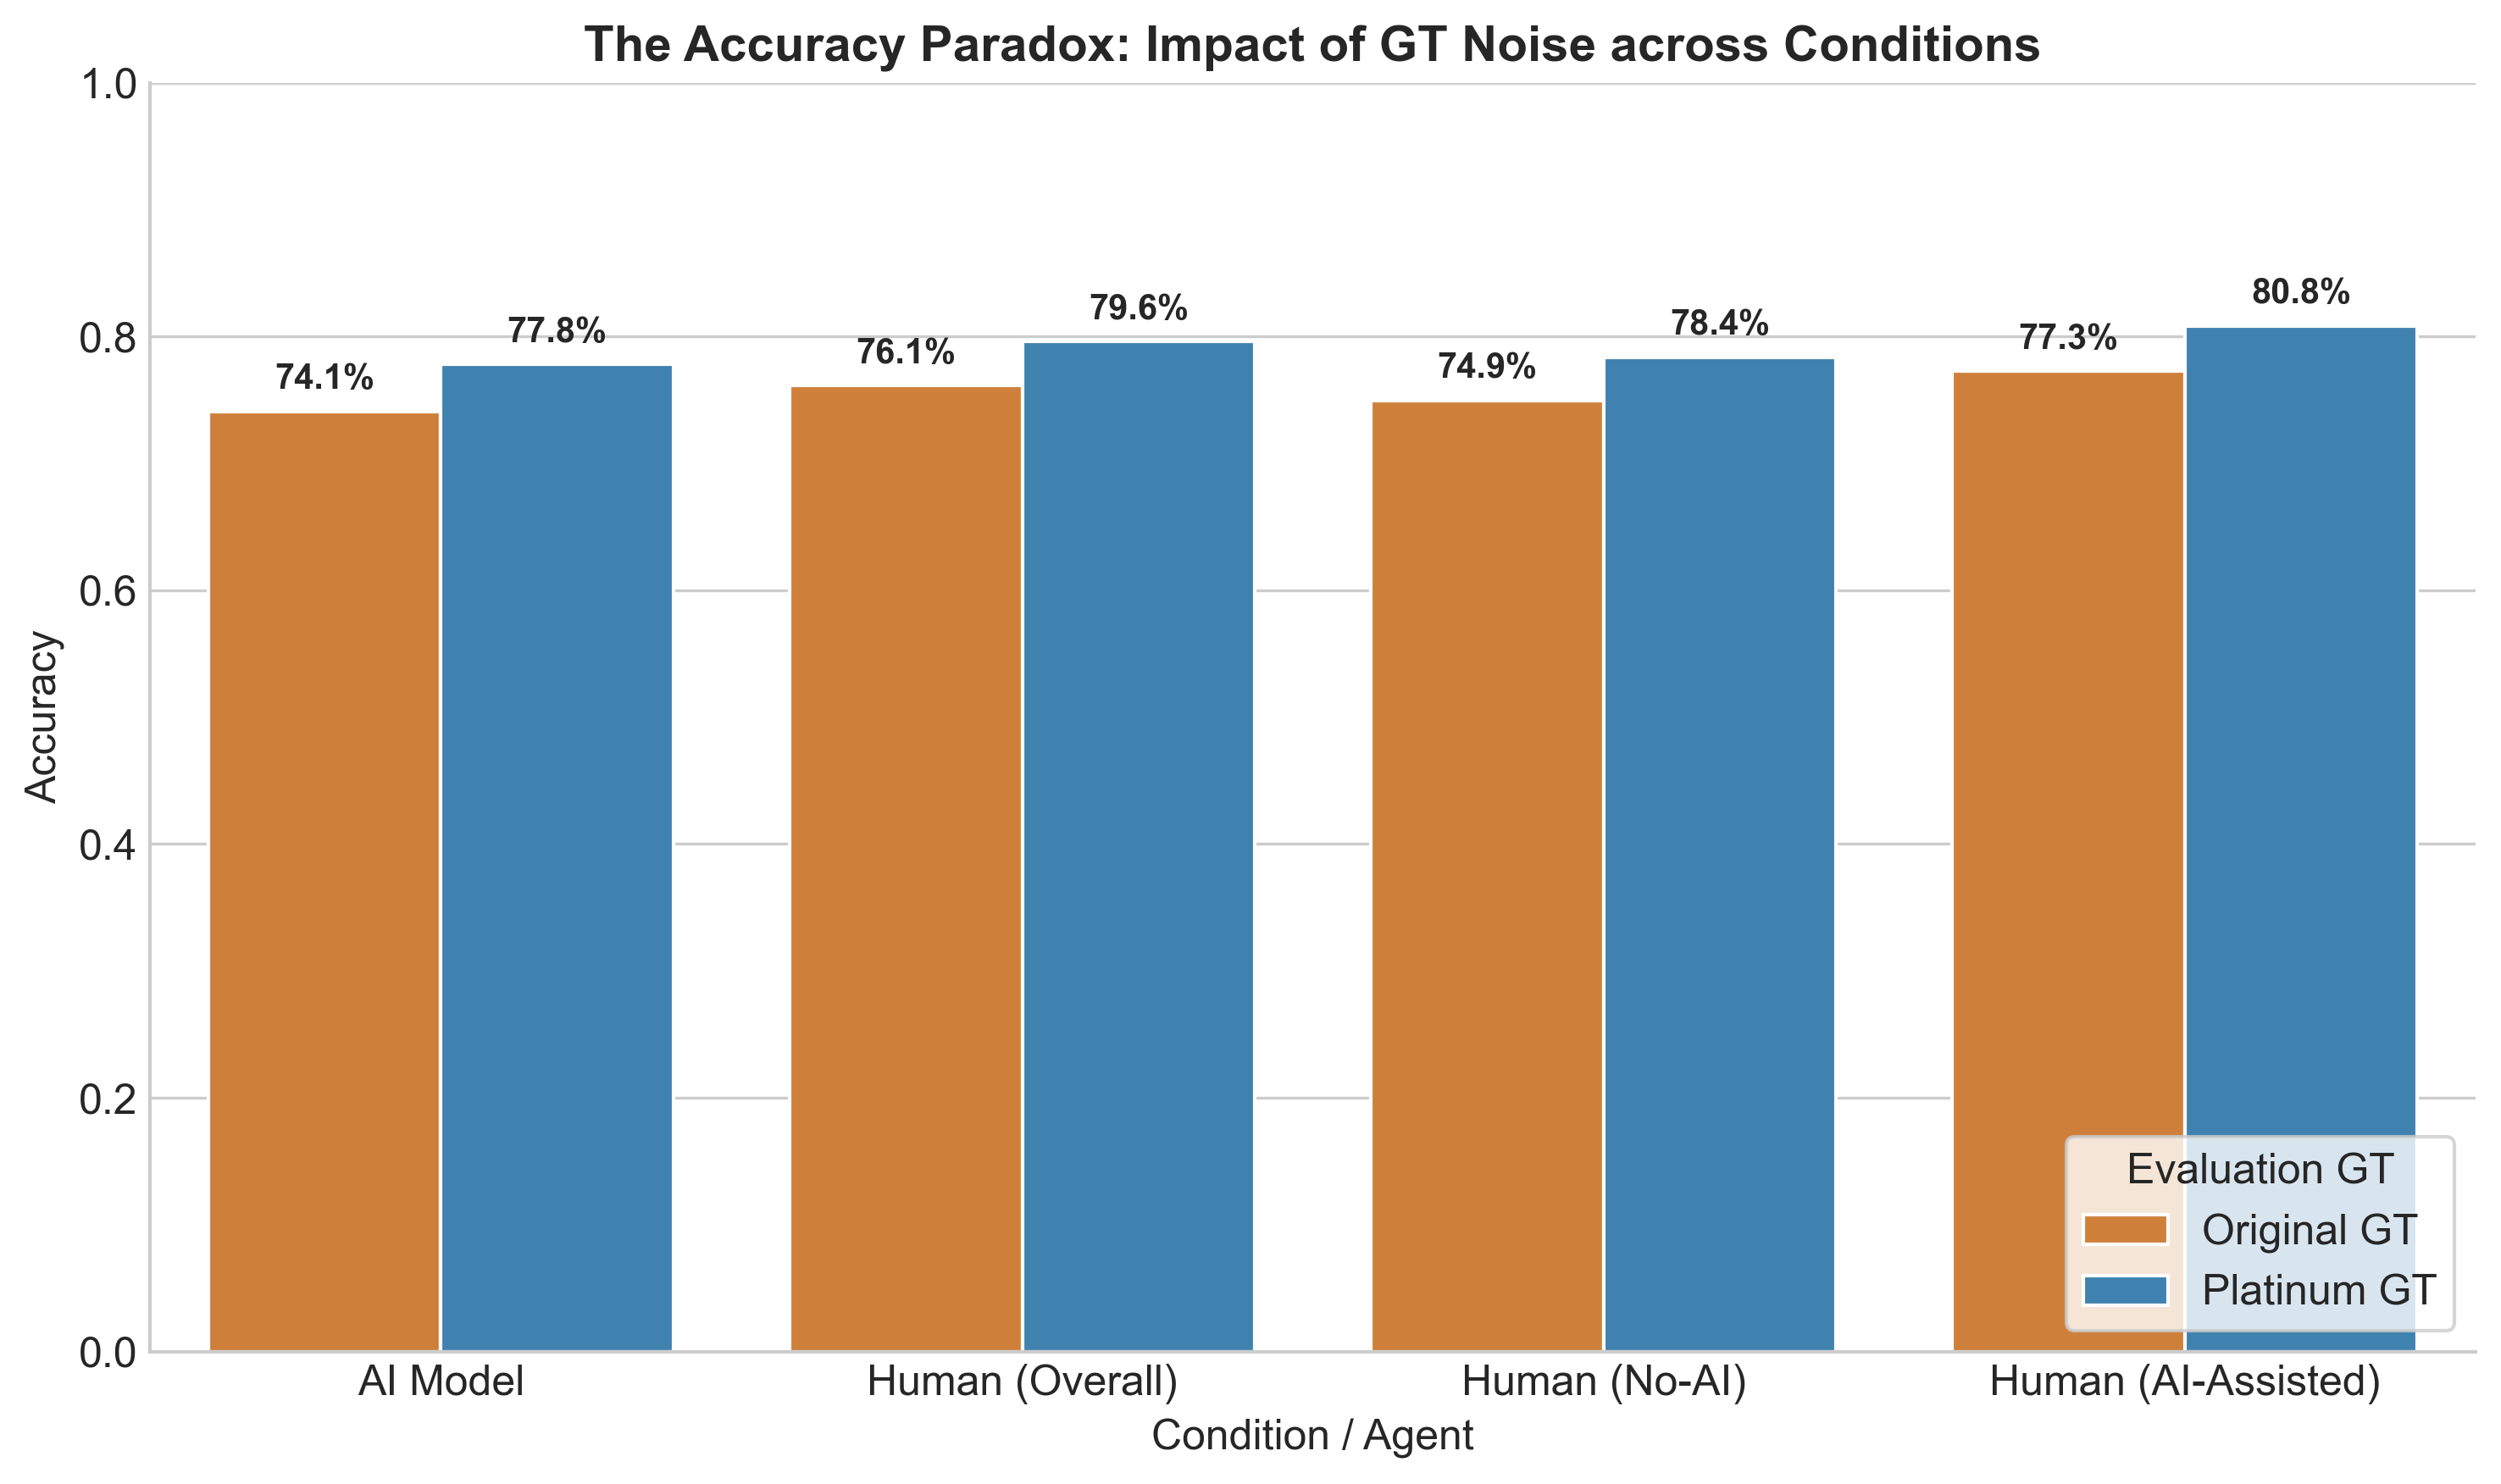

In [5]:
print("Generating Fig 3: Accuracy Paradox")

# Use df_exclude (Strategy A) as requested
df_acc = helpers.load_data('exclude', filter_completers=True)

# 1. AI Model Accuracy (evaluated on unique images to reflect inherent performance)
df_unique = df_acc.drop_duplicates('trial_image_name')
ai_orig = df_unique['ai_correct_original'].mean()
ai_plat = df_unique['ai_correct_plat'].mean()

# 2. Human (Overall) Accuracy
h_overall_orig = df_acc['human_correct_original'].mean()
h_overall_plat = df_acc['human_correct_plat'].mean()

# 3. Human (No-AI Condition) Accuracy
h_noai_orig = df_acc[df_acc['condition'] == 'no_ai']['human_correct_original'].mean()
h_noai_plat = df_acc[df_acc['condition'] == 'no_ai']['human_correct_plat'].mean()

# 4. Human (AI-Assisted Condition) Accuracy
h_ai_orig = df_acc[df_acc['condition'] == 'ai']['human_correct_original'].mean()
h_ai_plat = df_acc[df_acc['condition'] == 'ai']['human_correct_plat'].mean()

# Construct plotting dataframe
plot_data = pd.DataFrame([
    {'Agent': 'AI Model', 'Ground Truth': 'Original GT', 'Accuracy': ai_orig},
    {'Agent': 'AI Model', 'Ground Truth': 'Platinum GT', 'Accuracy': ai_plat},
    {'Agent': 'Human (Overall)', 'Ground Truth': 'Original GT', 'Accuracy': h_overall_orig},
    {'Agent': 'Human (Overall)', 'Ground Truth': 'Platinum GT', 'Accuracy': h_overall_plat},
    {'Agent': 'Human (No-AI)', 'Ground Truth': 'Original GT', 'Accuracy': h_noai_orig},
    {'Agent': 'Human (No-AI)', 'Ground Truth': 'Platinum GT', 'Accuracy': h_noai_plat},
    {'Agent': 'Human (AI-Assisted)', 'Ground Truth': 'Original GT', 'Accuracy': h_ai_orig},
    {'Agent': 'Human (AI-Assisted)', 'Ground Truth': 'Platinum GT', 'Accuracy': h_ai_plat}
])

# Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=plot_data, x='Agent', y='Accuracy', hue='Ground Truth', palette=['#E67E22', '#2E86C1'])

# Aesthetics and Labeling
ax.set_ylim(0, 1.0)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Condition / Agent', fontsize=12)
ax.set_title('The Accuracy Paradox: Impact of GT Noise across Conditions', fontsize=14, fontweight='bold')
ax.legend(title='Evaluation GT', loc='lower right', frameon=True)

# Add value labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1%}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
save_fig(plt.gcf(), 'Fig3_Accuracy_Paradox')
plt.show()


## Figure 4: Reliance Taxonomy

Generating Fig 4: Reliance Taxonomy


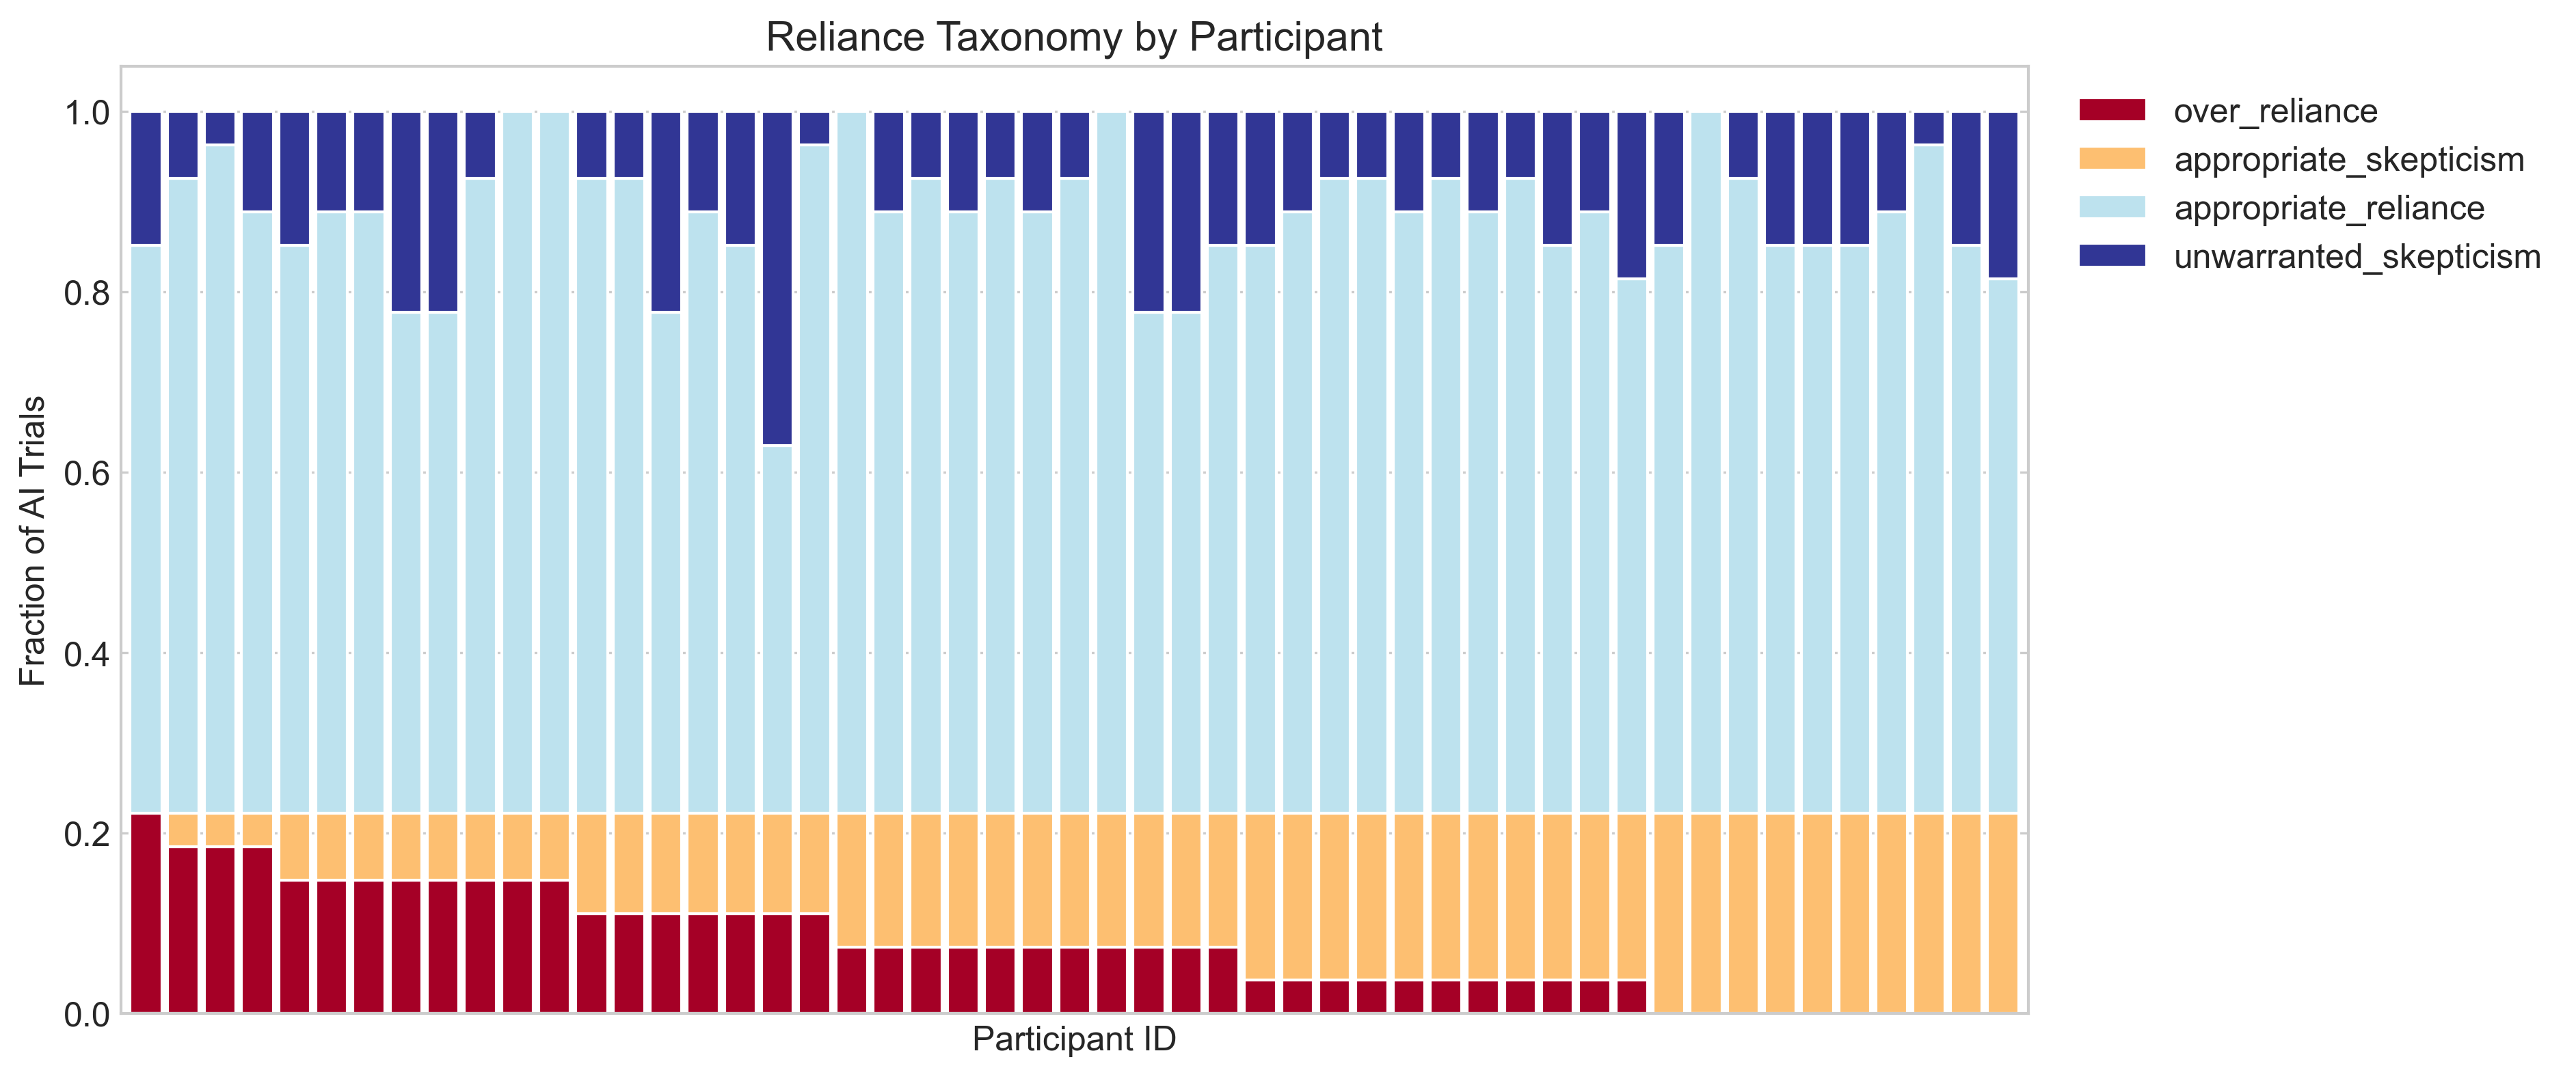

In [6]:
print("Generating Fig 4: Reliance Taxonomy")

ai_df = df[df['condition'] == 'ai']
rel_cols = ['over_reliance', 'appropriate_skepticism', 'appropriate_reliance', 'unwarranted_skepticism']
rel_rates = ai_df.groupby('participant_id')[rel_cols].mean()
rel_rates = rel_rates.sort_values('over_reliance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
rel_rates.plot(kind='bar', stacked=True, colormap='RdYlBu', ax=ax, width=0.85)
ax.set_title("Reliance Taxonomy by Participant")
ax.set_ylabel("Fraction of AI Trials")
ax.set_xlabel("Participant ID")
ax.set_xticks([]) # Hide participant IDs as they are just hashes
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

save_fig(fig, 'Fig4_Reliance_Taxonomy')
plt.show()


## Figure 5: AI Confidence on Mislabeled Images

Generating Fig 5: AI Confidence on Mislabeled Images


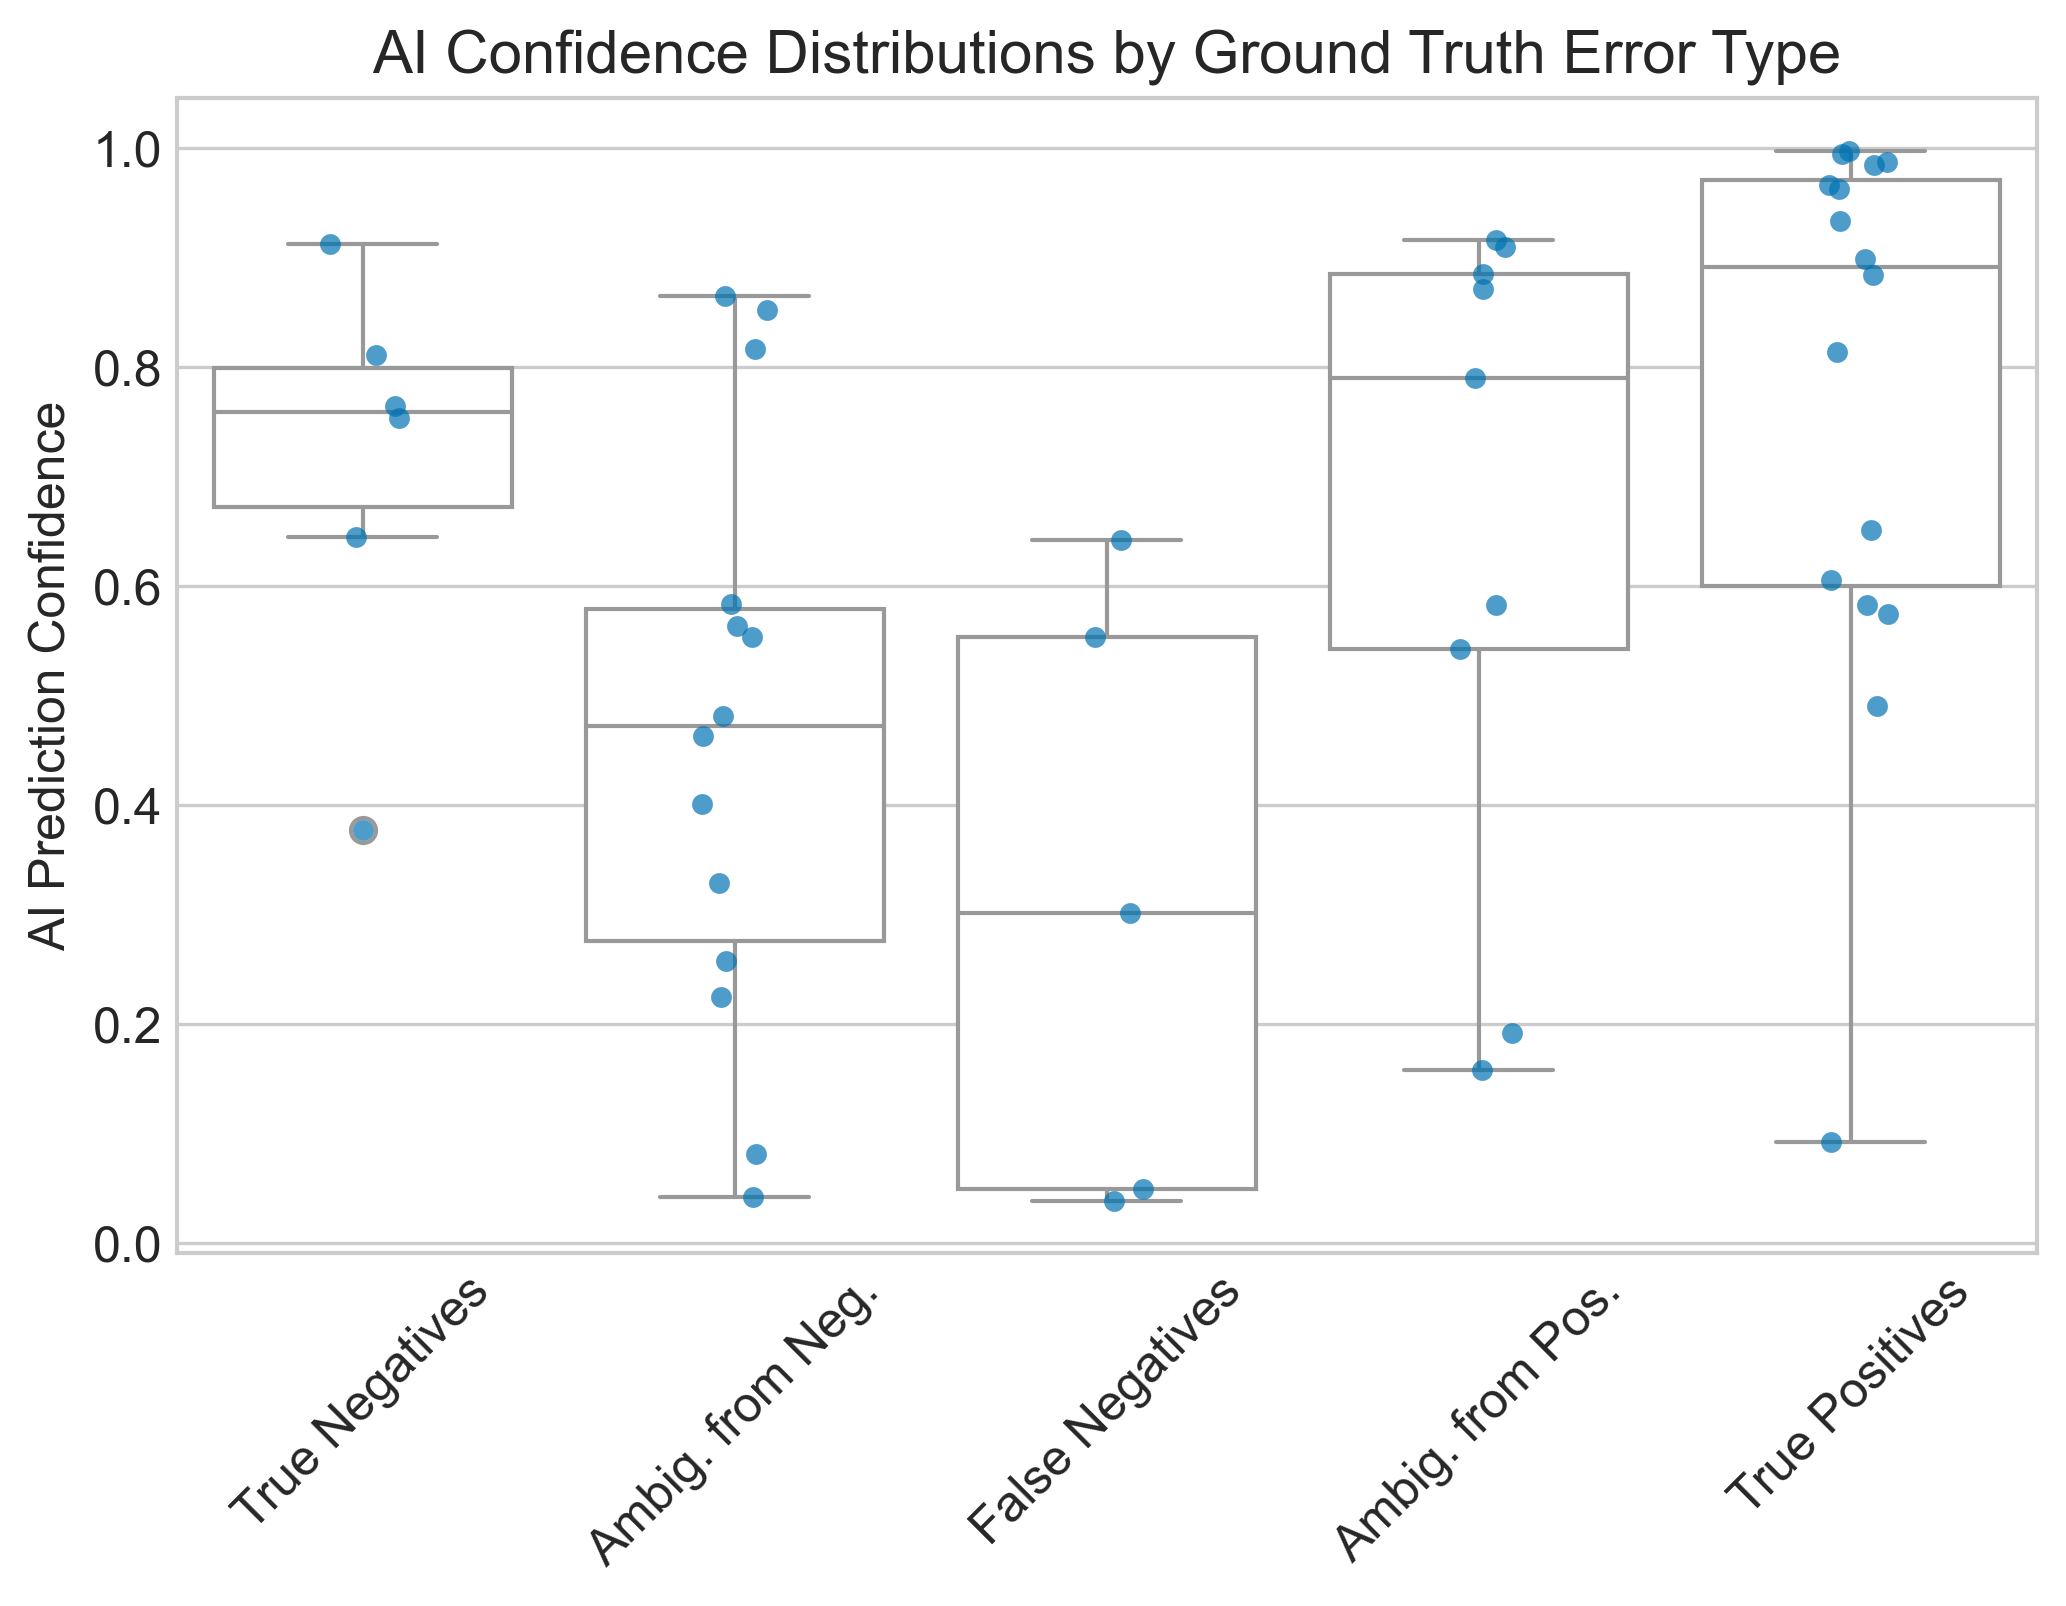

In [7]:
print("Generating Fig 5: AI Confidence on Mislabeled Images")

fig, ax = plt.subplots(figsize=(8, 5))
order = ['stable_neg', 'ambig_from_neg', 'fn_corrected', 'ambig_from_pos', 'stable_pos']
sns.boxplot(data=df_img, x='label_direction', y='ai_confidence', order=order, ax=ax, color='white')
sns.stripplot(data=df_img, x='label_direction', y='ai_confidence', order=order, ax=ax, alpha=0.7, jitter=True)

ax.set_title("AI Confidence Distributions by Ground Truth Error Type")
ax.set_xticklabels(['True Negatives', 'Ambig. from Neg.', 'False Negatives', 'Ambig. from Pos.', 'True Positives'], rotation=45)
ax.set_ylabel("AI Prediction Confidence")
ax.set_xlabel("")

save_fig(fig, 'Fig5_AI_Confidence_Mislabeled')
plt.show()


## Figure 6: Decision Flip Map

Generating Fig 6: Decision Flip Map


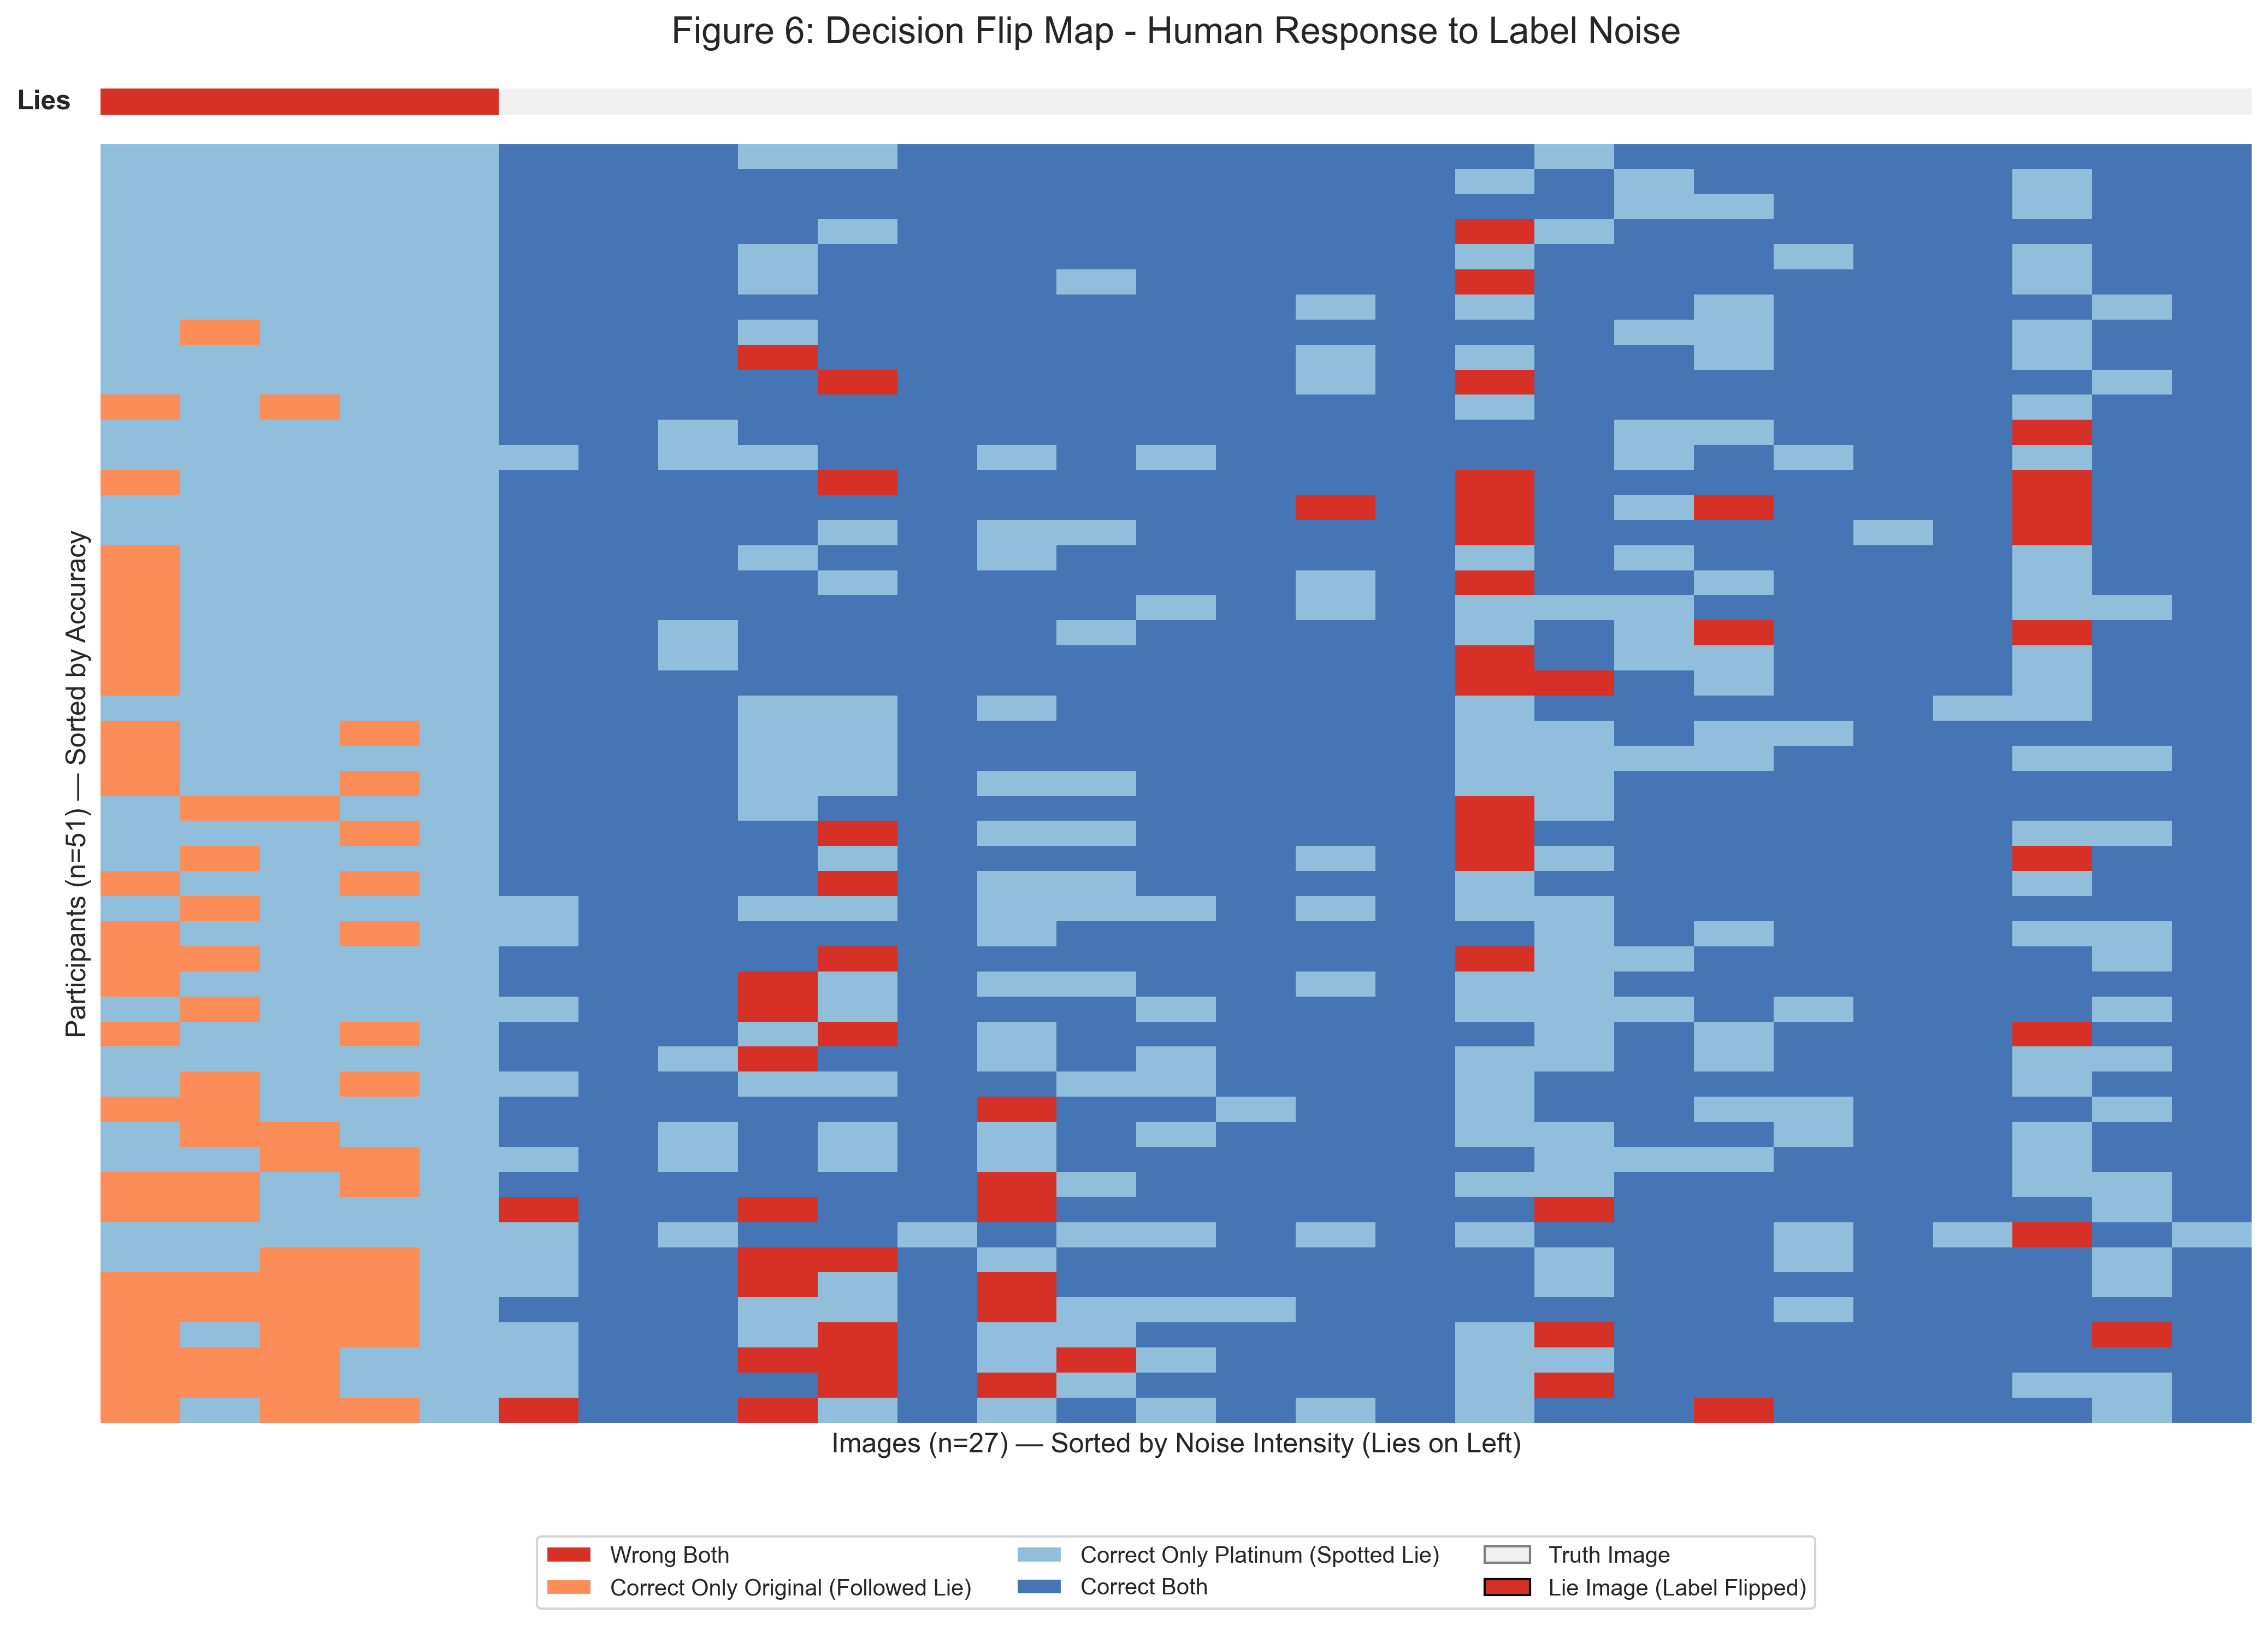

In [8]:
print("Generating Fig 6: Decision Flip Map")

# 1. Prepare Image Sorting by Noise Intensity
# Calculate absolute difference between original and platinum KL scores as noise intensity
df_img['noise_intensity'] = (df_img['gt_original'] - df_img['gt_plat_kl']).abs()

# Only include images present in the current 'exclude' analysis
current_images = df['trial_image_name'].unique()
df_img_sorted = df_img[df_img['image_name'].isin(current_images)].copy()

# Sort: Lies first (label_changed=True), then by noise intensity
df_img_sorted = df_img_sorted.sort_values(['label_changed', 'noise_intensity'], ascending=[False, False])
sorted_images = df_img_sorted['image_name'].tolist()

# 2. Prepare Participant Sorting (by average accuracy on Platinum GT)
participant_order = df_part.sort_values('accuracy_plat', ascending=False)['participant_id'].tolist()

# 3. Create Pivot Matrix and Reorder
pivot_orig = df.pivot_table(index='participant_id', columns='trial_image_name', values='human_correct_orig_int')
pivot_plat = df.pivot_table(index='participant_id', columns='trial_image_name', values='human_correct_plat_int')

# Highlight inversions: 1=Correct under orig, 2=Correct under plat, 3=Correct under both
diff = pivot_orig + pivot_plat * 2

# Reorder columns (images) and rows (participants)
diff = diff.reindex(columns=sorted_images, index=participant_order)

# 4. Plot with Noise Indicator
fig, (ax_noise, ax) = plt.subplots(2, 1, figsize=(14, 10), 
                                   gridspec_kw={'height_ratios': [0.02, 0.98]},
                                   sharex=True)

# Top bar indicating "Lies" (where labels were flipped)
lie_indicator = df_img_sorted['label_changed'].astype(int).values.reshape(1, -1)
sns.heatmap(lie_indicator, cmap=["#f0f0f0", "#d73027"], cbar=False, ax=ax_noise)
ax_noise.set_yticks([])
ax_noise.set_ylabel("Lies", rotation=0, labelpad=25, va='center', fontweight='bold')
ax_noise.set_title("Figure 6: Decision Flip Map - Human Response to Label Noise", fontsize=16, pad=20)

# Main Heatmap
# Colors: 0=Wrong Both, 1=Followed Lie, 2=Spotted Lie, 3=Correct Both
cmap = sns.color_palette(["#d73027", "#fc8d59", "#91bfdb", "#4575b4"])
sns.heatmap(diff, cmap=cmap, cbar=False, ax=ax)

# Axis labels and cleanup
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlabel(f"Images (n={len(sorted_images)}) — Sorted by Noise Intensity (Lies on Left)", fontsize=12)
ax.set_ylabel(f"Participants (n={len(participant_order)}) — Sorted by Accuracy", fontsize=12)

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d73027', label='Wrong Both'),
    Patch(facecolor='#fc8d59', label='Correct Only Original (Followed Lie)'),
    Patch(facecolor='#91bfdb', label='Correct Only Platinum (Spotted Lie)'),
    Patch(facecolor='#4575b4', label='Correct Both'),
    Patch(facecolor='#f0f0f0', label='Truth Image', edgecolor='gray'),
    Patch(facecolor='#d73027', label='Lie Image (Label Flipped)', edgecolor='black')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncol=3, fontsize=10, frameon=True)

plt.tight_layout()
save_fig(fig, 'Fig6_Decision_Flip_Map')
plt.show()

## Figure 7: Calibration Curves

Generating Fig 7: Calibration Curves


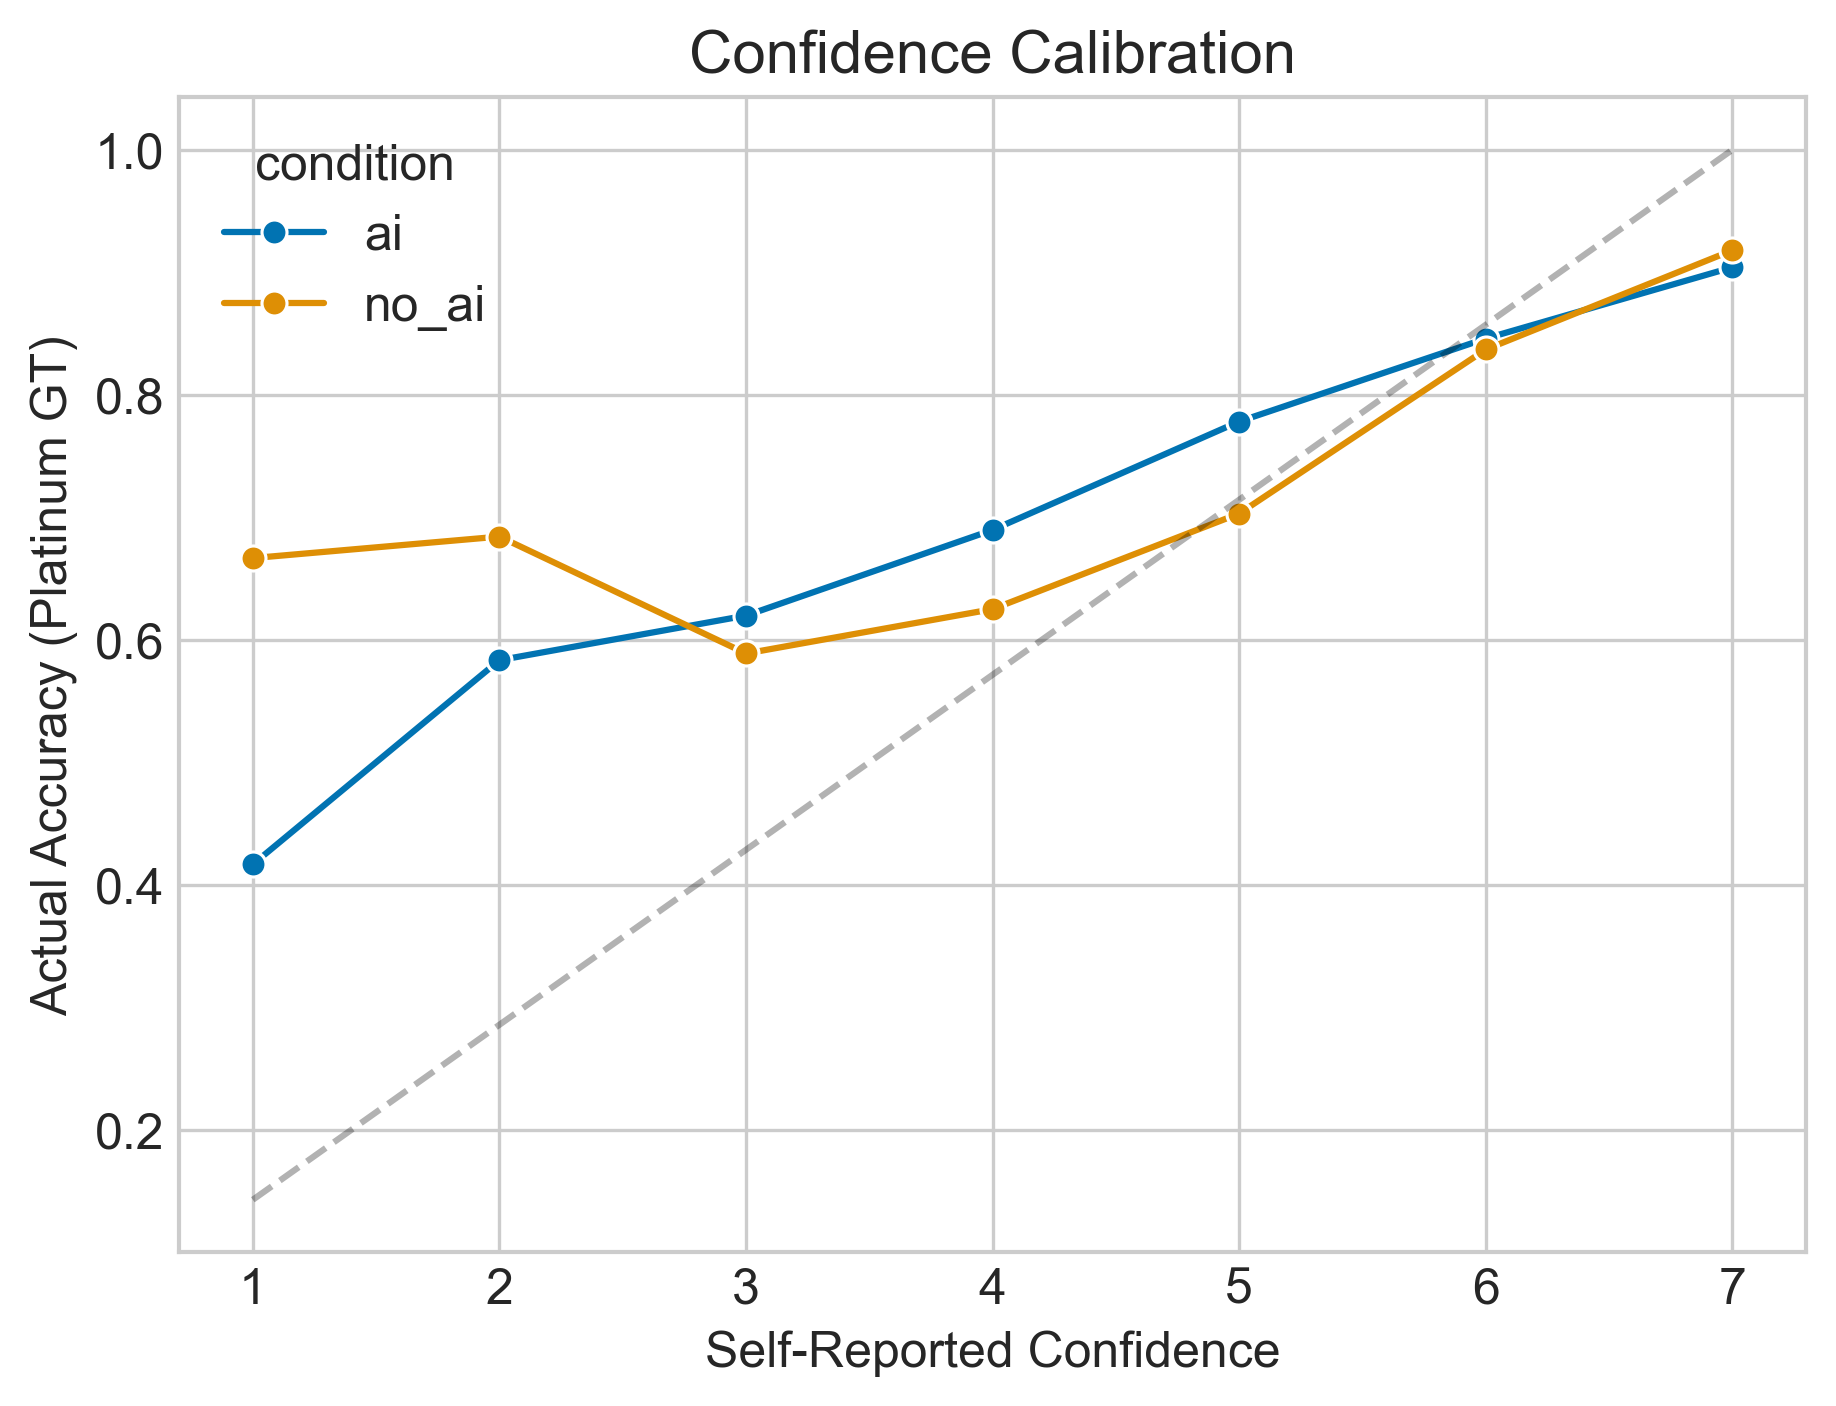

In [9]:
print("Generating Fig 7: Calibration Curves")

calib = df.groupby(['condition', 'final_confidence'])['human_correct_plat'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(data=calib, x='final_confidence', y='human_correct_plat', hue='condition', marker='o', ax=ax)
ax.plot([1, 7], [1/7, 1], 'k--', alpha=0.3)
ax.set_title("Confidence Calibration")
ax.set_ylabel("Actual Accuracy (Platinum GT)")
ax.set_xlabel("Self-Reported Confidence")

save_fig(fig, 'Fig7_Calibration_Curves')
plt.show()


## Figure 8: Psychometric Heatmap

Generating Fig 8: Psychometric Heatmap


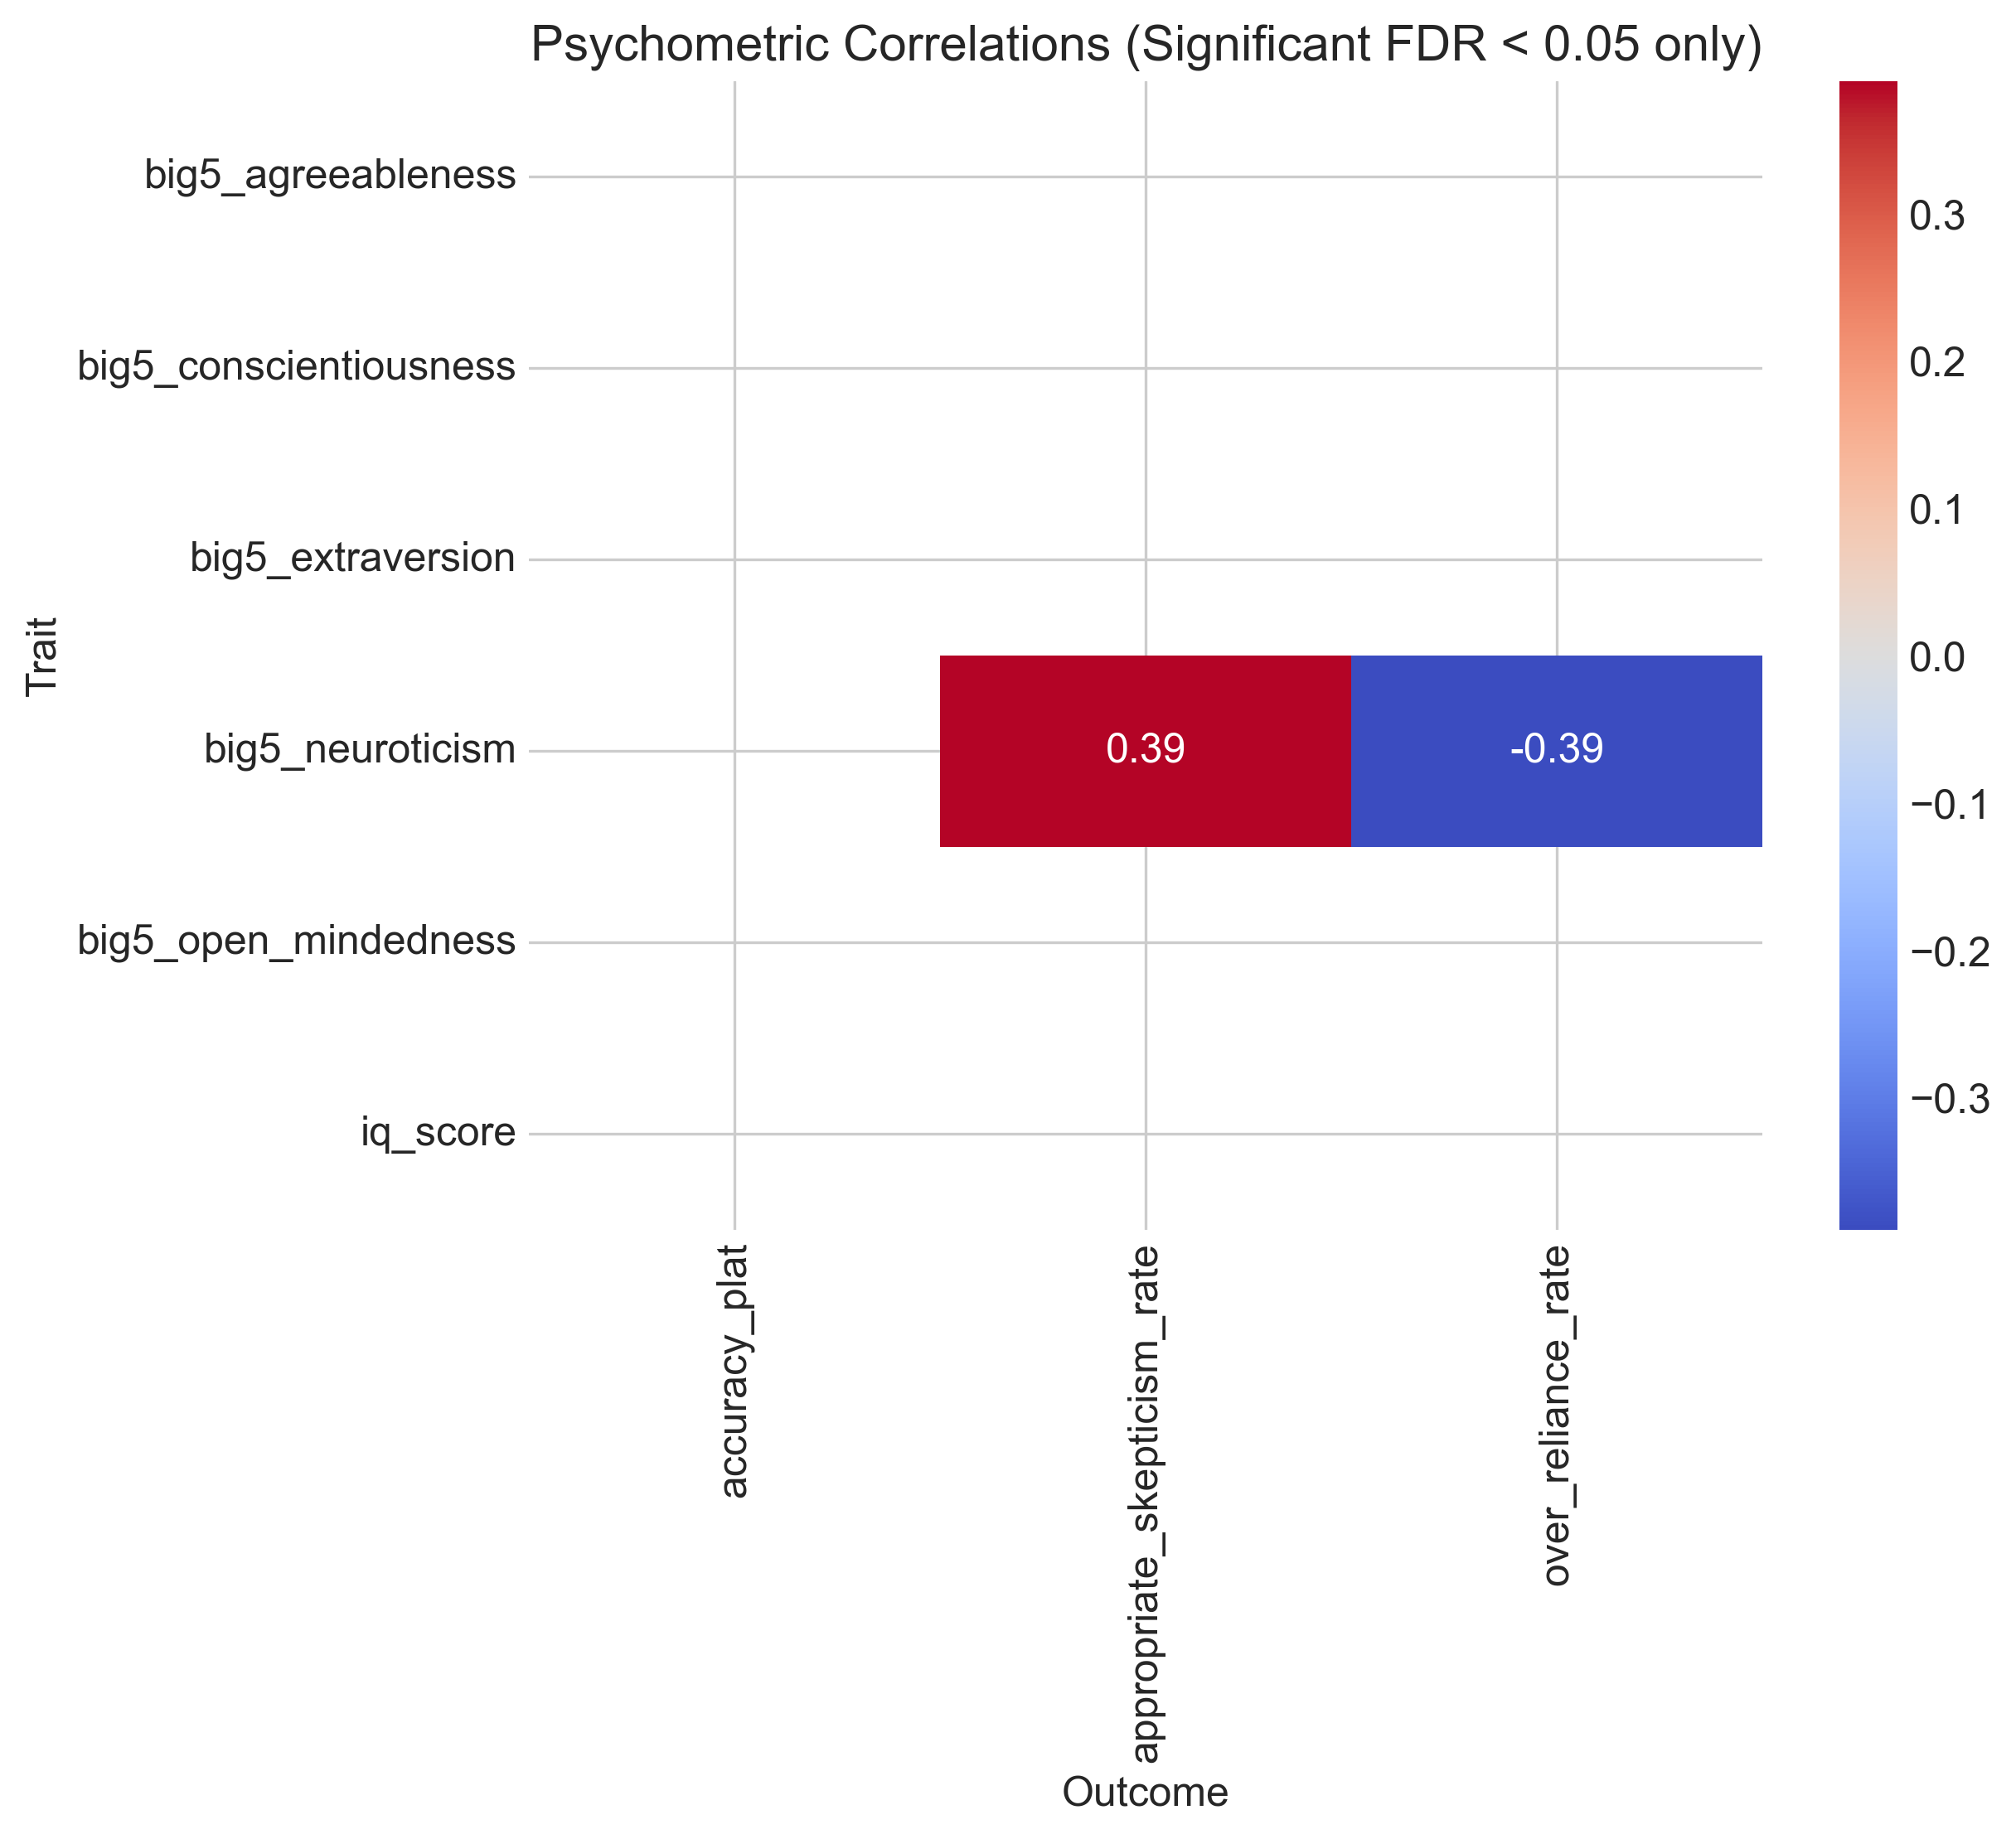

In [10]:
print("Generating Fig 8: Psychometric Heatmap")

b5_cols = ['big5_open_mindedness', 'big5_conscientiousness', 'big5_extraversion', 'big5_agreeableness', 'big5_neuroticism', 'iq_score']
outcomes = ['accuracy_plat', 'over_reliance_rate', 'appropriate_skepticism_rate']
res_psy = []
for out in outcomes:
    for c in b5_cols:
        r, p = stats.spearmanr(df_part[c], df_part[out], nan_policy='omit')
        res_psy.append({'Trait': c, 'Outcome': out, 'r': r, 'p_raw': p})

psy_df = pd.DataFrame(res_psy)
psy_df['p_fdr'] = multipletests(psy_df['p_raw'], method='fdr_bh')[1]

pivot_r = psy_df.pivot(index='Trait', columns='Outcome', values='r')
pivot_p = psy_df.pivot(index='Trait', columns='Outcome', values='p_fdr')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_r, mask=(pivot_p > 0.05), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title("Psychometric Correlations (Significant FDR < 0.05 only)")

save_fig(fig, 'Fig8_Psychometric_Heatmap')
plt.show()


## Figure 9: Learning Curves

Generating Fig 9: Learning Curves


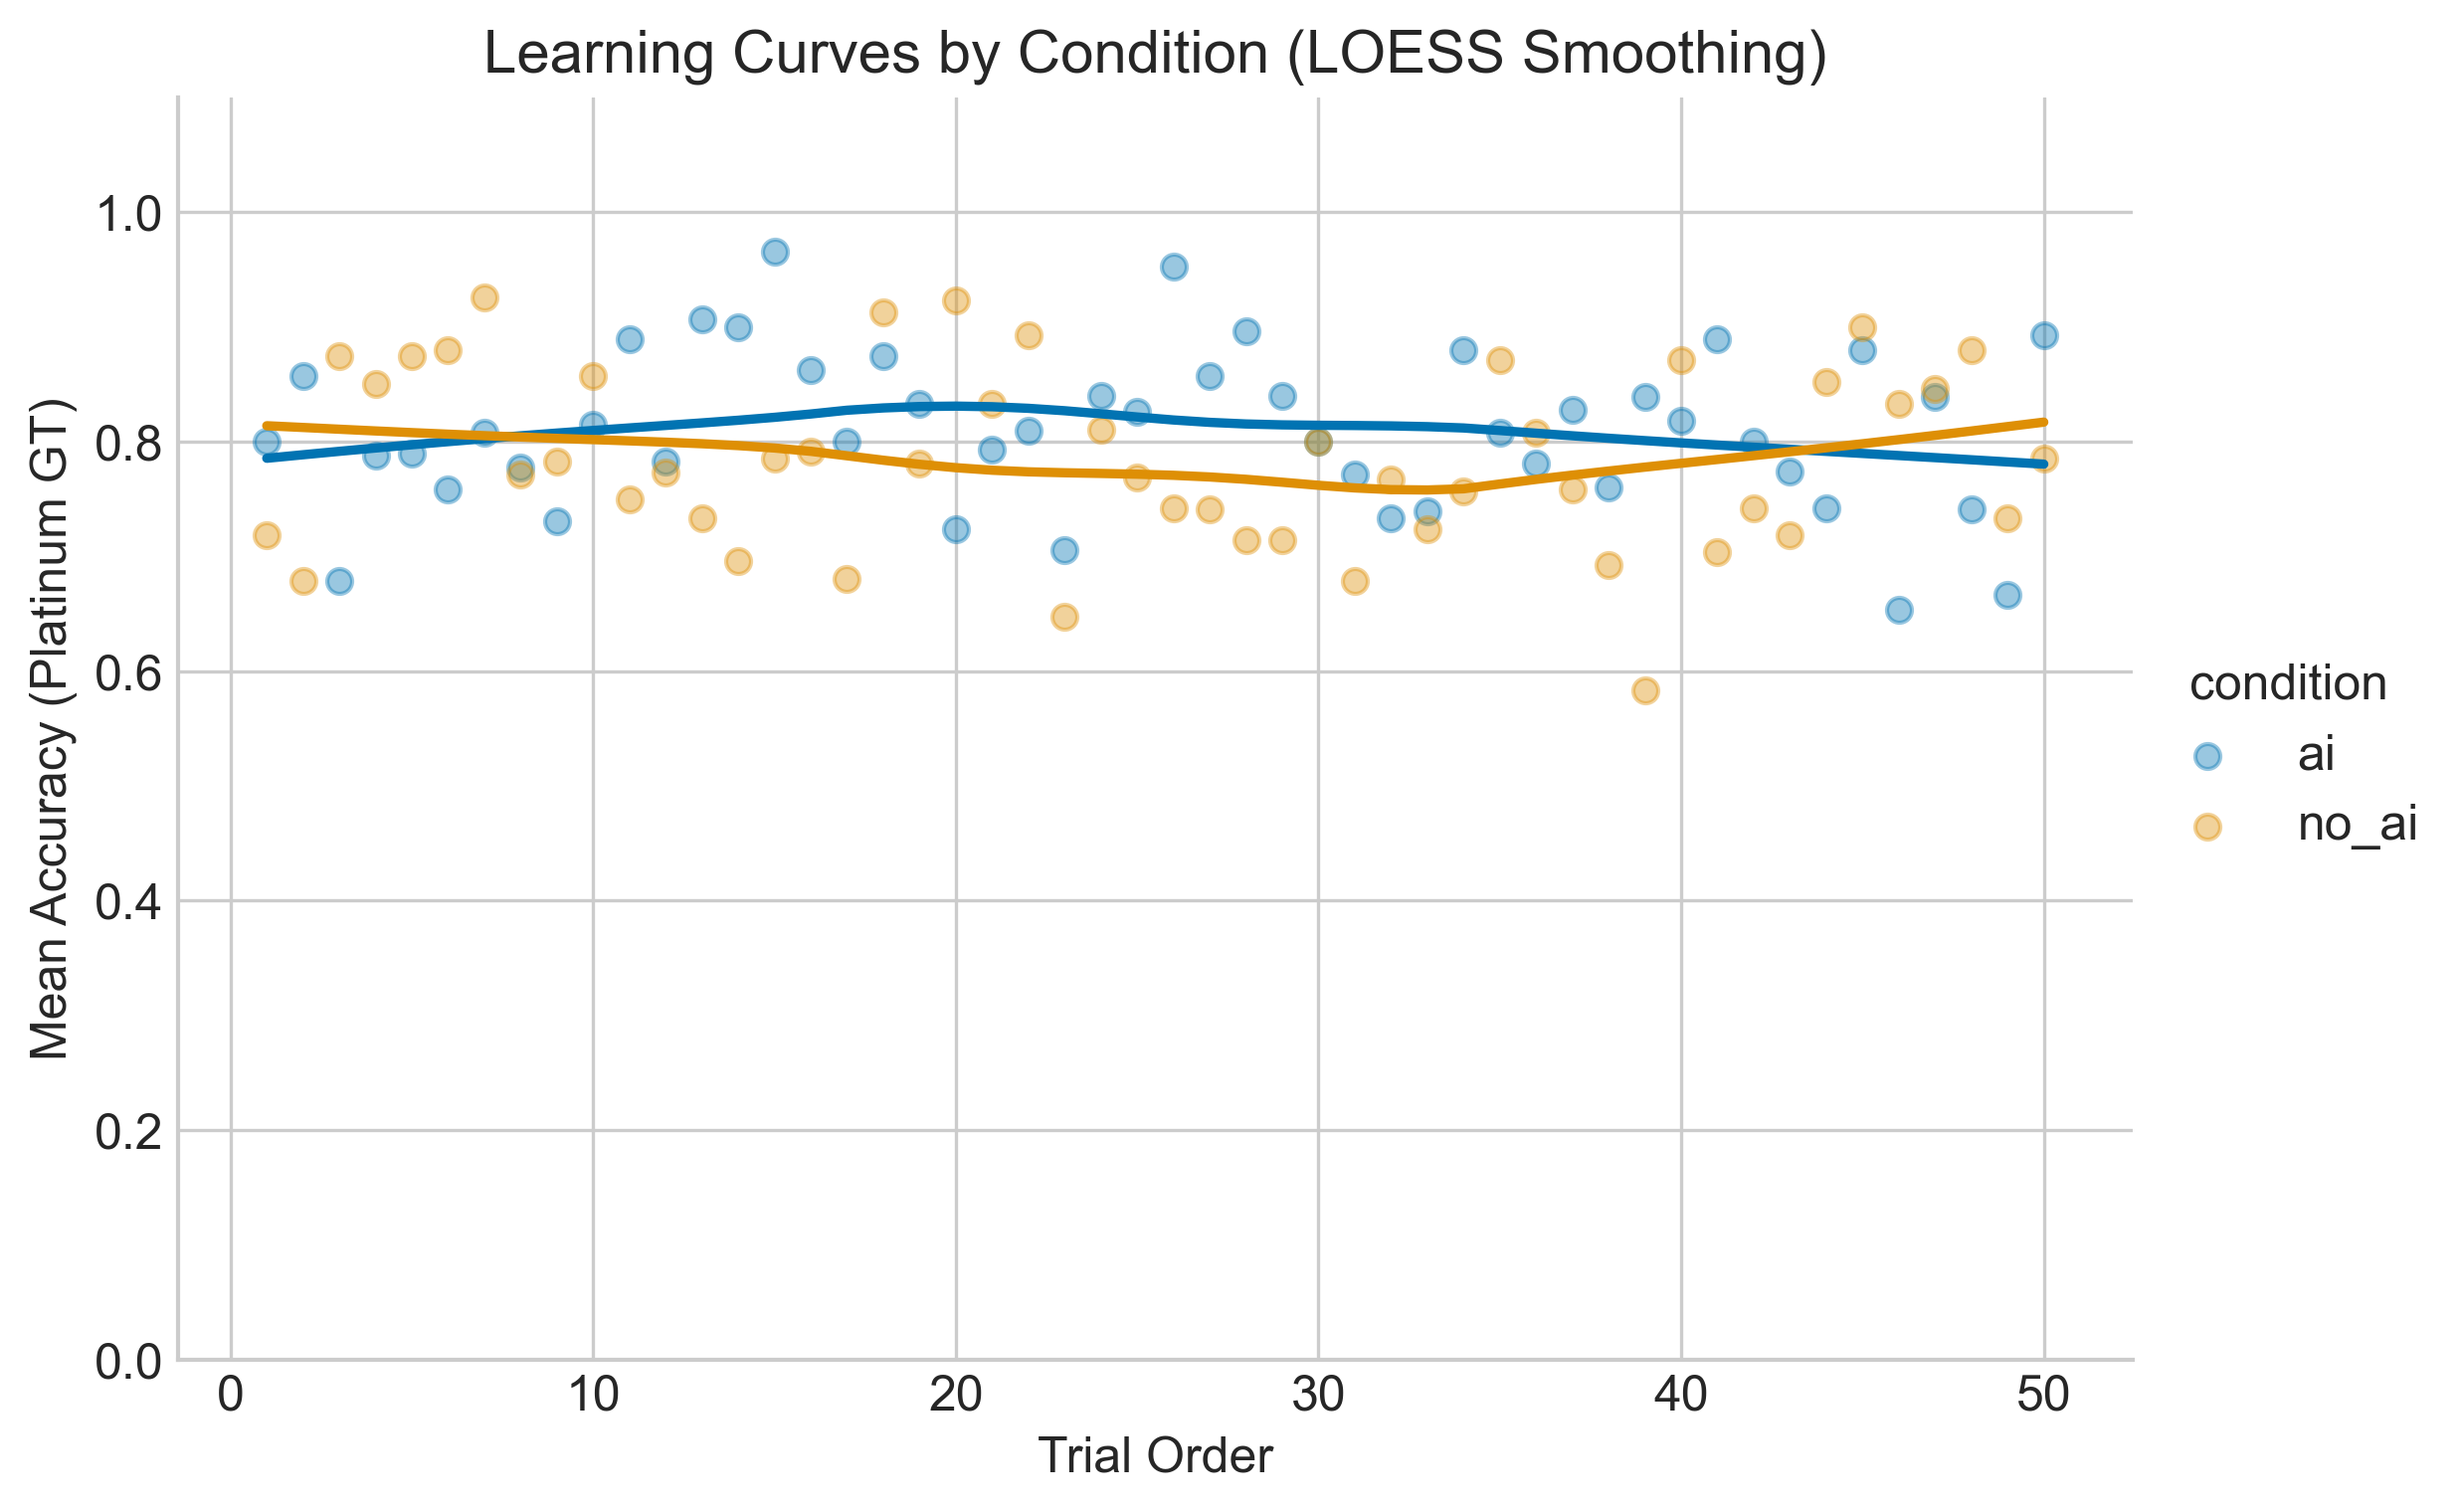

In [11]:
print("Generating Fig 9: Learning Curves")

# Step 1: Aggregate data by condition and trial order to calculate mean accuracy
mean_accuracy_by_trial_order = df.groupby(['condition', 'trial_order'])['human_correct_plat_int'].mean().reset_index()

# Step 2: Use sns.lmplot on the aggregated dataframe with lowess=True
# This will plot separate LOESS lines for 'AI' and 'No-AI' on the same axes
g = sns.lmplot(
    data=mean_accuracy_by_trial_order, 
    x='trial_order', 
    y='human_correct_plat_int', 
    hue='condition', 
    lowess=True, 
    height=5, 
    aspect=1.5,
    scatter_kws={'alpha': 0.4} # Optional: makes raw trial means subtle
)

# Step 3: Formatting and Saving
plt.title('Learning Curves by Condition (LOESS Smoothing)')
plt.ylabel('Mean Accuracy (Platinum GT)')
plt.xlabel('Trial Order')
plt.ylim(0, 1.1)

fig = plt.gcf()
save_fig(fig, 'Fig9_Learning_Curves')
plt.show()


## Figure 10: Model Comparison

Generating Fig 10: Model Comparison Coefficient Plot


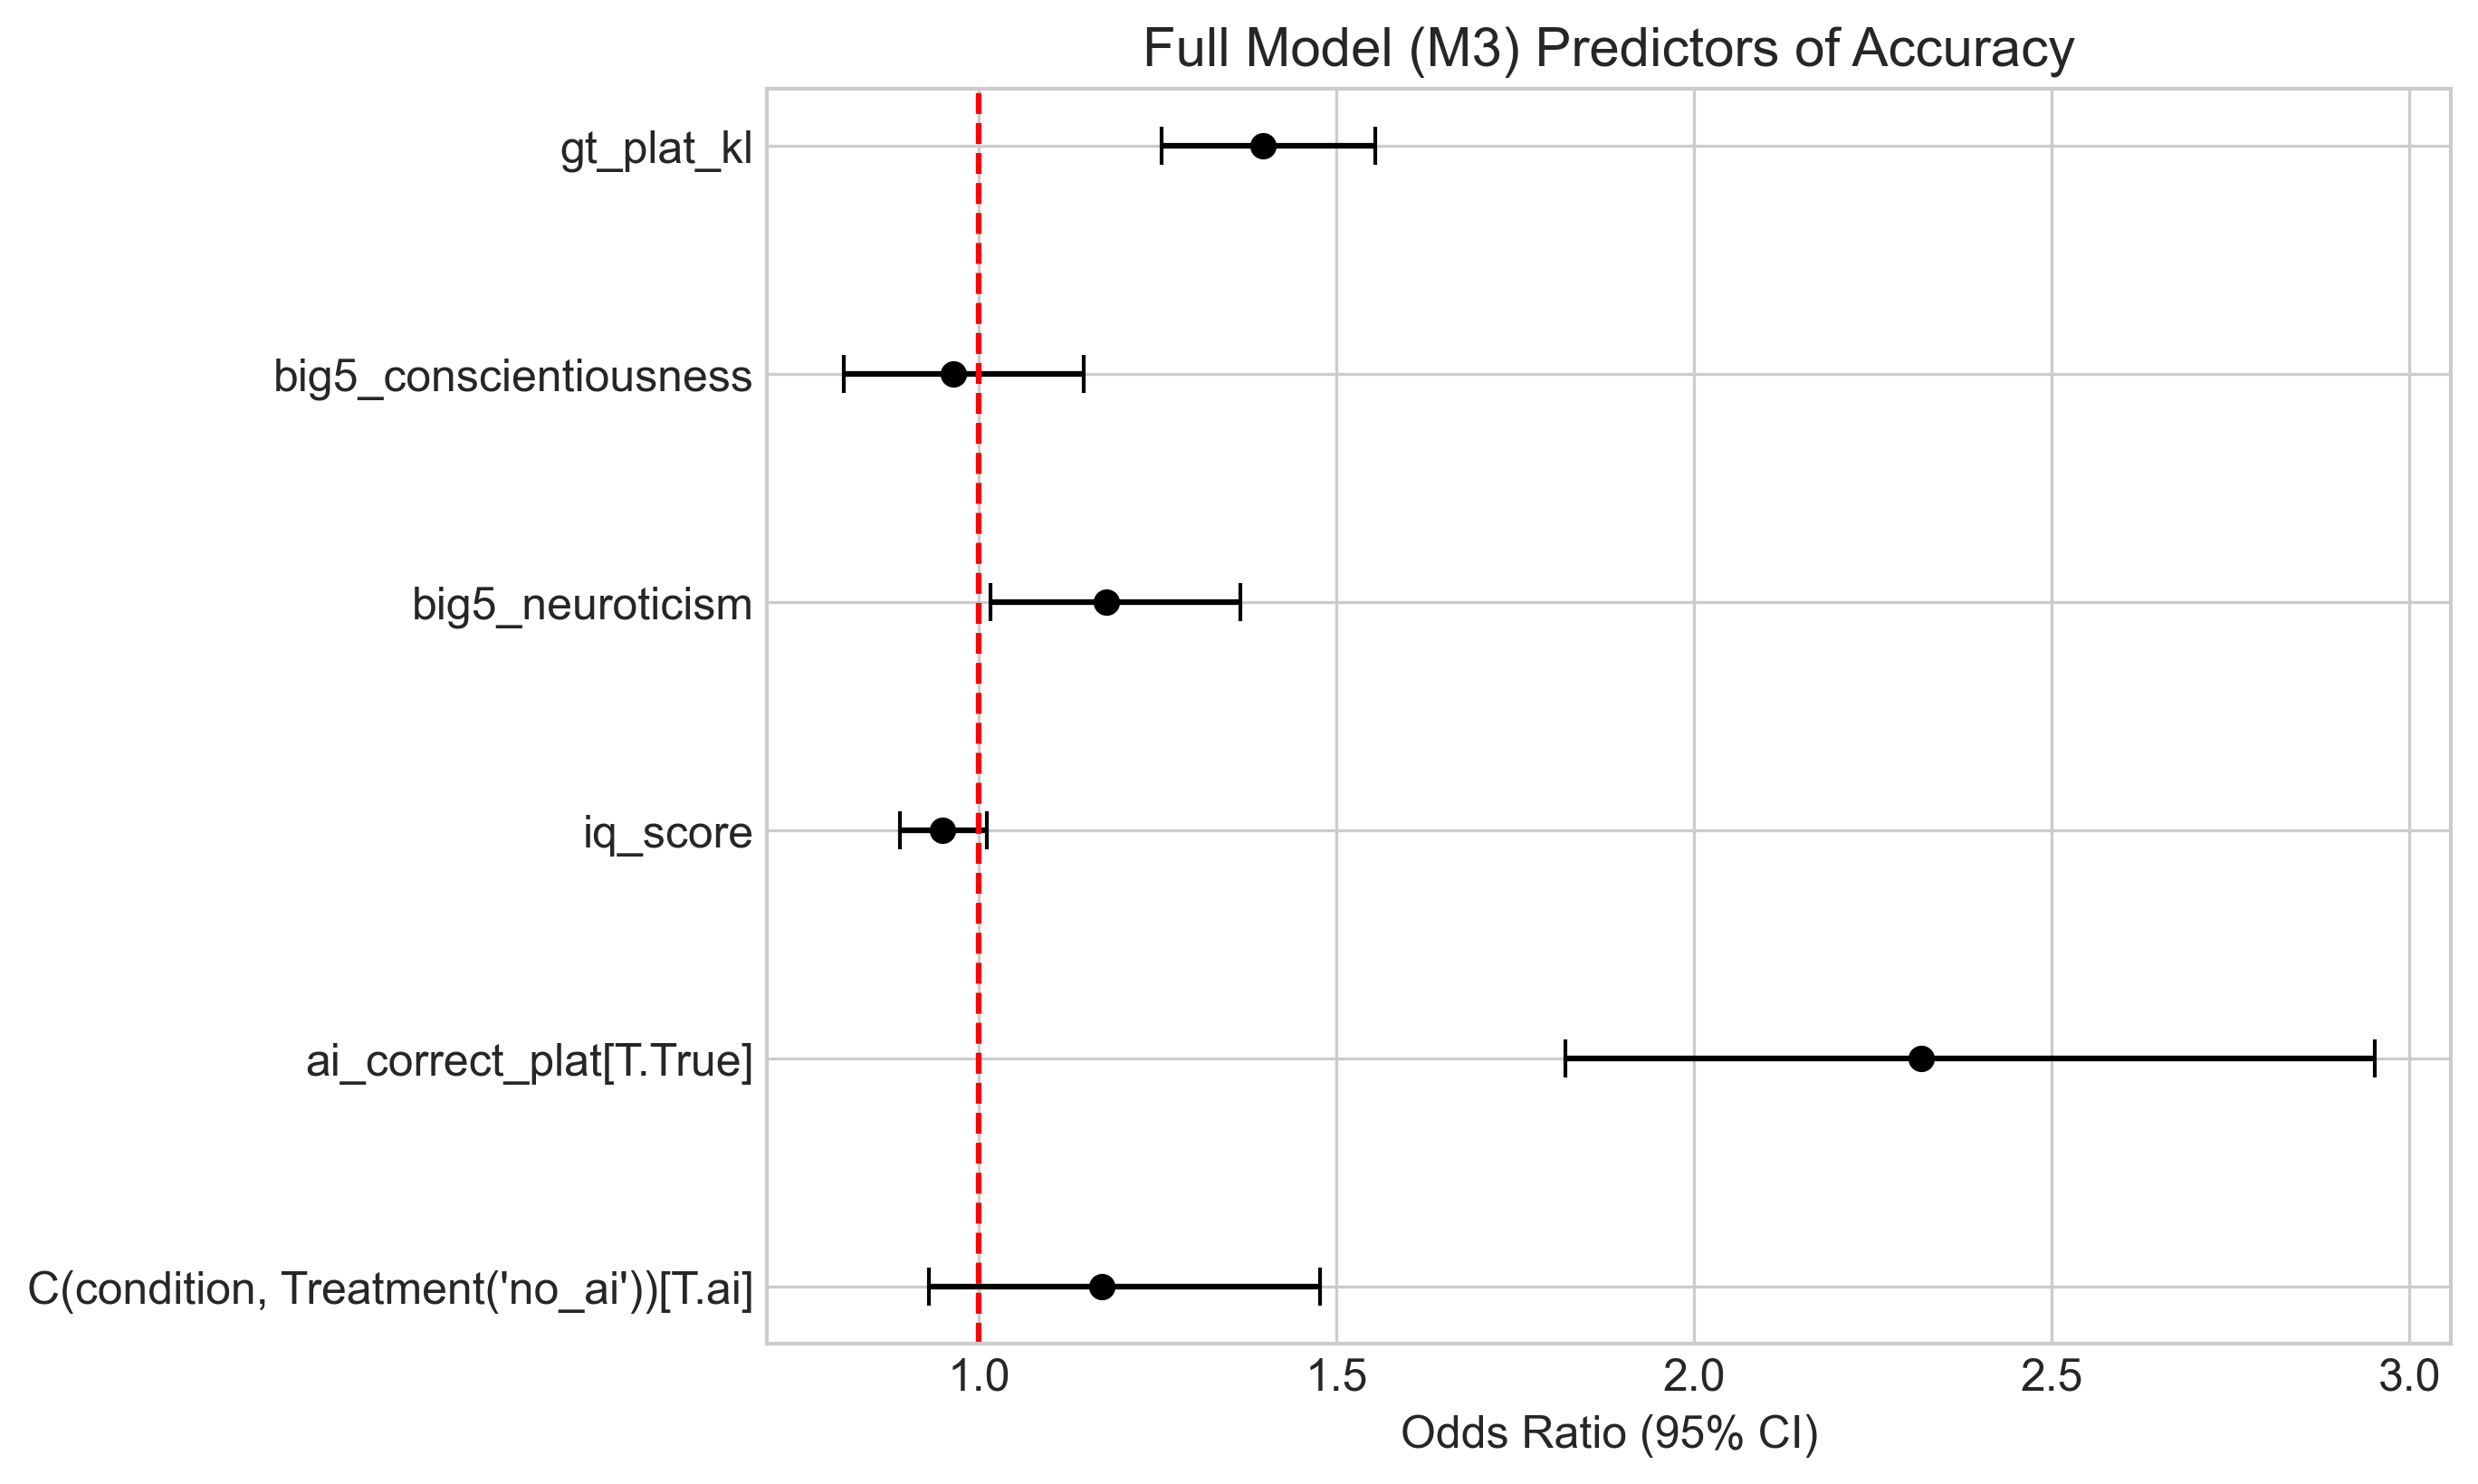

In [12]:
print("Generating Fig 10: Model Comparison Coefficient Plot")

m3 = smf.gee("human_correct_plat_int ~ C(condition, Treatment('no_ai')) + iq_score + big5_neuroticism + big5_conscientiousness + gt_plat_kl + ai_correct_plat", 
             groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()

params = m3.params
conf = m3.conf_int()
conf['OR'] = np.exp(params)
conf.columns = ['Lower CI', 'Upper CI', 'OR']
conf[['Lower CI', 'Upper CI']] = np.exp(conf[['Lower CI', 'Upper CI']])

# Exclude intercept
conf = conf.drop('Intercept')

fig, ax = plt.subplots(figsize=(8, 6))
# Calculate errors for errorbar (must be positive distances from the point)
y_err_lower = conf['OR'] - conf['Lower CI']
y_err_upper = conf['Upper CI'] - conf['OR']

ax.errorbar(conf['OR'], np.arange(len(conf)), xerr=[y_err_lower, y_err_upper], fmt='o', color='black', capsize=5)
ax.axvline(1, color='red', linestyle='--')
ax.set_yticks(np.arange(len(conf)))
ax.set_yticklabels(conf.index)
ax.set_xlabel("Odds Ratio (95% CI)")
ax.set_title("Full Model (M3) Predictors of Accuracy")

save_fig(fig, 'Fig10_Model_Comparison')
plt.show()
